<a href="https://www.kaggle.com/code/vedikagupta0/catboost-churn-prediction-0-91?scriptVersionId=304496184" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [462]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
df_og = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [463]:
df_og.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [464]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [465]:
id_col = ['id', 'customerID']

In [466]:
df_og.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [467]:
df2.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


##### no null values were observed

In [468]:
df2.shape

(7043, 21)

In [469]:
df_og.shape

(594194, 21)

In [470]:
df = pd.concat([df_og, df2], axis=0)

In [471]:
df.drop(columns=id_col, inplace=True)

In [472]:
df.shape

(601237, 20)

In [473]:
xcols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['all_same_services'] = df[xcols].nunique(axis=1) == 1
tf['all_same_services'] = tf[xcols].nunique(axis=1) == 1

In [474]:
df['all_same_services'].value_counts()

all_same_services
False    355386
True     245851
Name: count, dtype: int64

In [475]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [476]:
df = df.reset_index(drop=True)

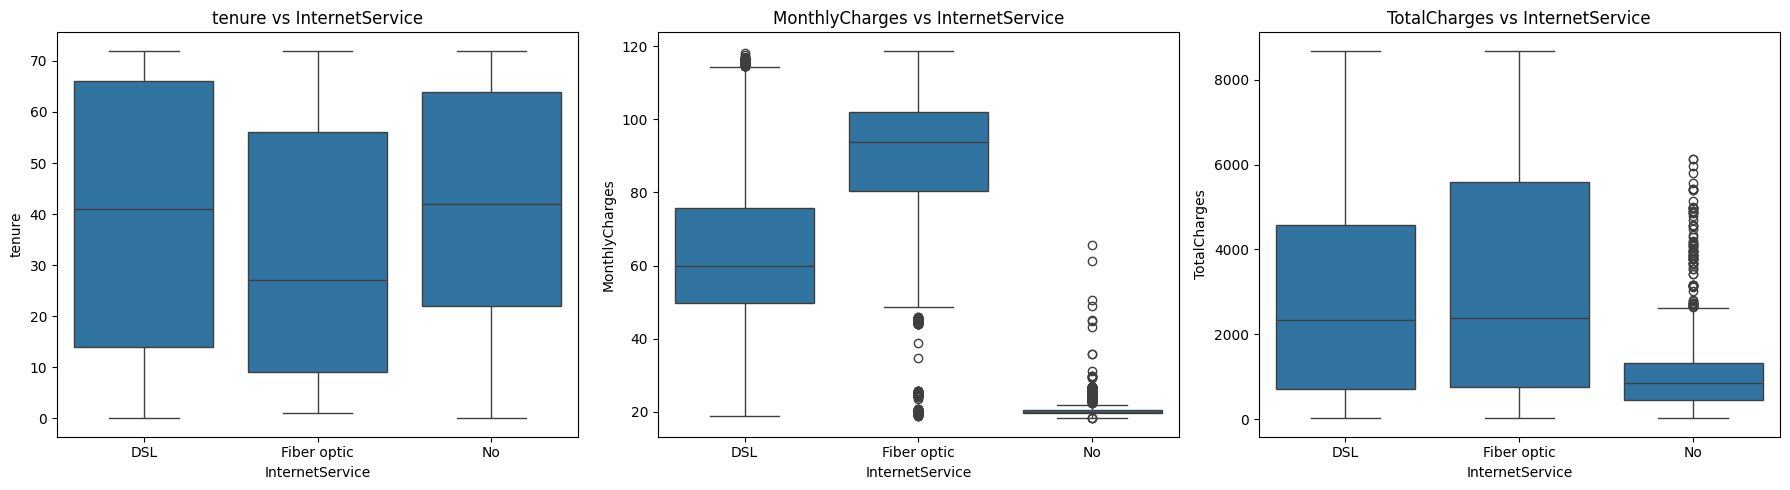

In [477]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        x="InternetService",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs InternetService")

plt.tight_layout()
plt.show()

In [478]:
cat_cols = df.describe(include='object').columns[:-1]

In [479]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df_og['Churn'] = df_og['Churn'].map({'No':0, 'Yes':1})

In [480]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 'No internet service').all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(142253, 21)

In [481]:
no_int= 100 - ((df.shape[0] - 140727)/ df.shape[0])*100
print(f'{round(no_int,2)}% is having no internet service in {cols}')

23.41% is having no internet service in ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']


In [482]:
dup = df.duplicated().sum()
print(f'{round(dup,3)} % duplicate values exist in our df.')

22 % duplicate values exist in our df.


In [483]:
df.drop_duplicates(inplace=True)

In [484]:
df['dominance_of_nointernetservice'] = (df[cols] == 'No internet service').all(axis=1)
tf['dominance_of_nointernetservice'] = (tf[cols] == 'No internet service').all(axis=1)

In [485]:
df.dominance_of_nointernetservice.value_counts()

dominance_of_nointernetservice
False    458976
True     142239
Name: count, dtype: int64

In [486]:
df['is_fixed_contract_time'] = df['Contract'].apply(lambda x : True if 'year' in x else False)
tf['is_fixed_contract_time'] = tf['Contract'].apply(lambda x : True if 'year' in x else False)
df['is_automatic_payment'] = df['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)
tf['is_automatic_payment'] = tf['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)

In [487]:
encodings = {}

target = "Churn"

for col in cat_cols:
    mapping = df.groupby(col)[target].mean()
    encodings[col] = mapping

    print(f"{col} target encoding:")
    print(mapping.to_dict())
    print("-" * 40)

for col in cat_cols:
    df[col]    = df[col].map(encodings[col])
    df_og[col] = df_og[col].map(encodings[col])
    tf[col]    = tf[col].map(encodings[col])

gender target encoding:
{'Female': 0.2285006187586444, 'Male': 0.22280156657090205}
----------------------------------------
Partner target encoding:
{'No': 0.3246663590729171, 'Yes': 0.134478968289472}
----------------------------------------
Dependents target encoding:
{'No': 0.2915928285389233, 'Yes': 0.07374328082575766}
----------------------------------------
PhoneService target encoding:
{'No': 0.16964551280317983, 'Yes': 0.22933828637865275}
----------------------------------------
MultipleLines target encoding:
{'No': 0.18309898448833836, 'No phone service': 0.16964551280317983, 'Yes': 0.27712267550814473}
----------------------------------------
InternetService target encoding:
{'DSL': 0.10419618528610354, 'Fiber optic': 0.41539371850905343, 'No': 0.014925582997630749}
----------------------------------------
OnlineSecurity target encoding:
{'No': 0.40625469340942916, 'No internet service': 0.014925582997630749, 'Yes': 0.0875418644435342}
-------------------------------------

In [488]:
scaler = StandardScaler()
scale_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'all_same_services',
       'is_fixed_contract_time', 'is_automatic_payment',
       'dominance_of_nointernetservice']

df["charge_tenure_interaction"] = (
    df["TotalCharges"] *
    df["MonthlyCharges"] *
    df["tenure"]
)

tf["charge_tenure_interaction"] = (
    tf["TotalCharges"] *
    tf["MonthlyCharges"] *
    tf["tenure"]
)


df[scale_cols] = scaler.fit_transform(df[scale_cols])
tf[scale_cols] = scaler.transform(tf[scale_cols])

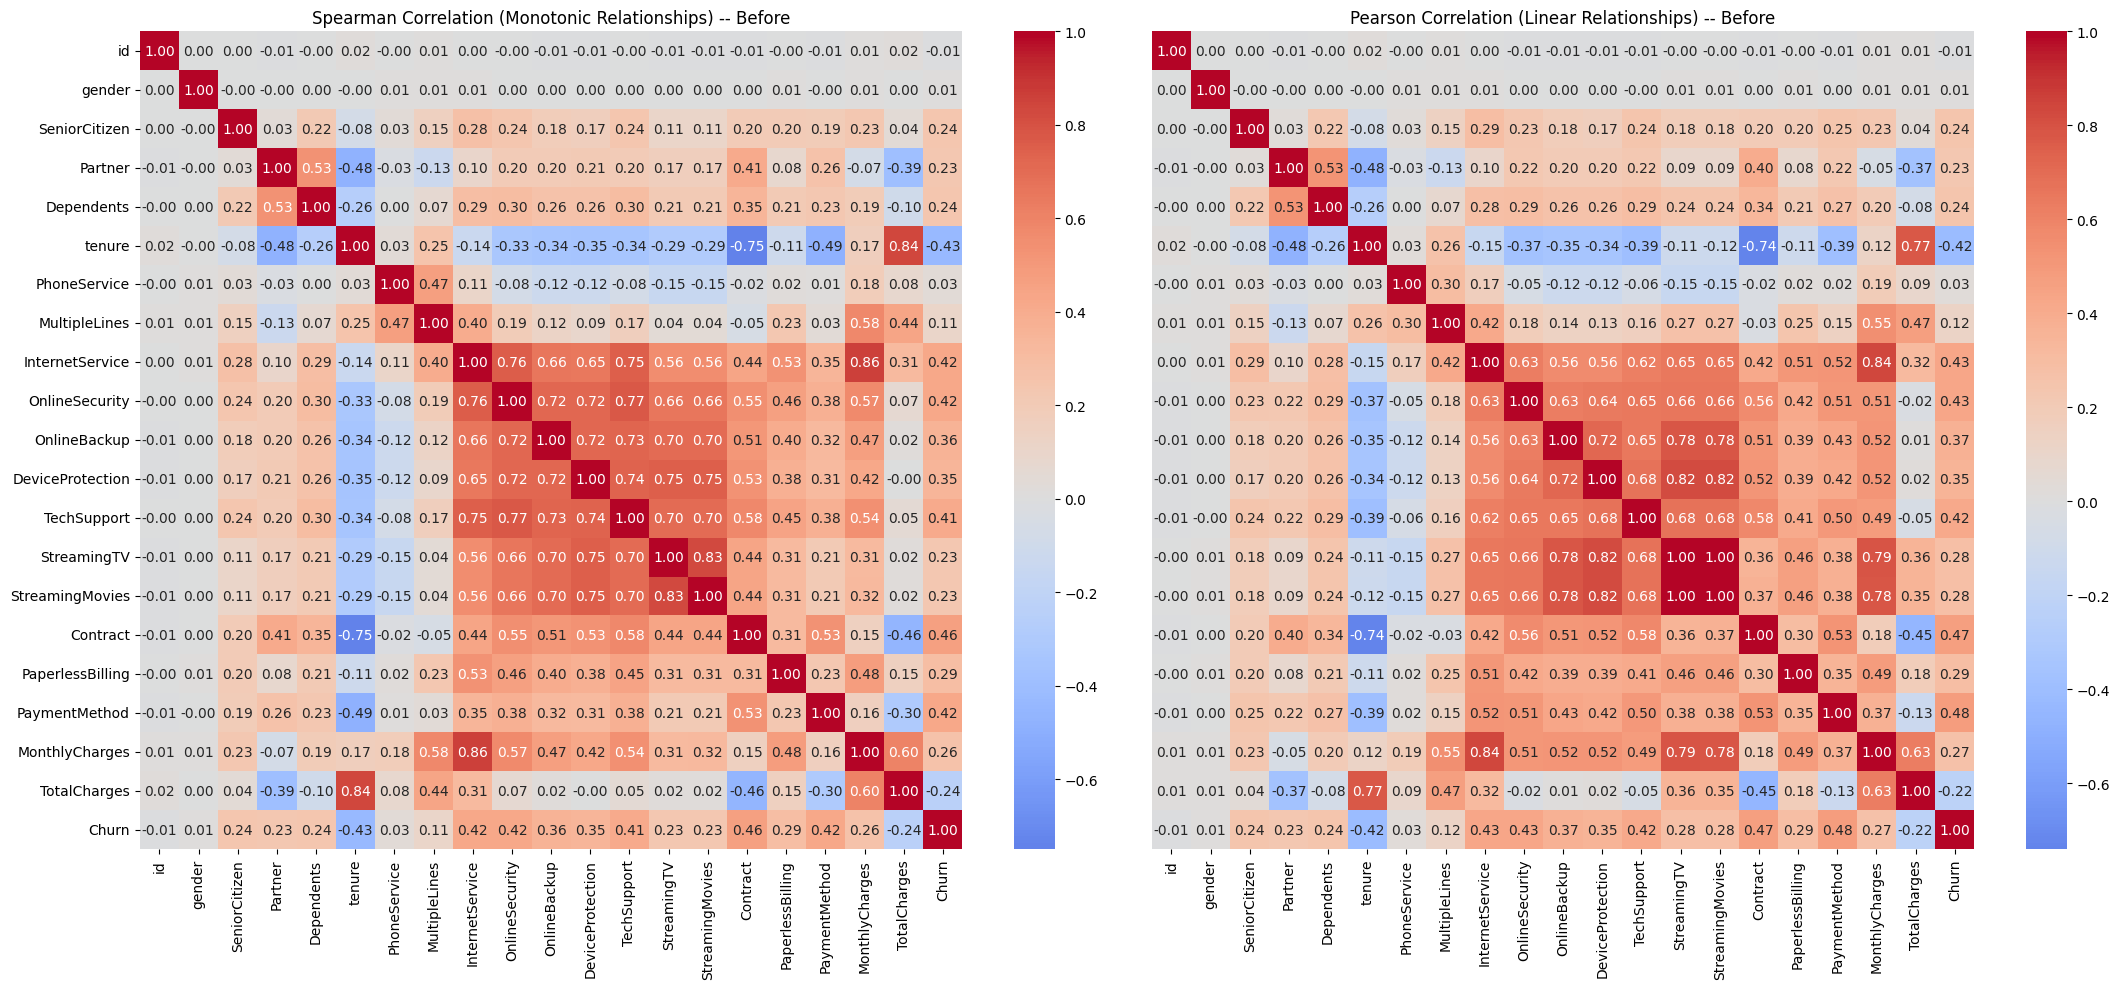

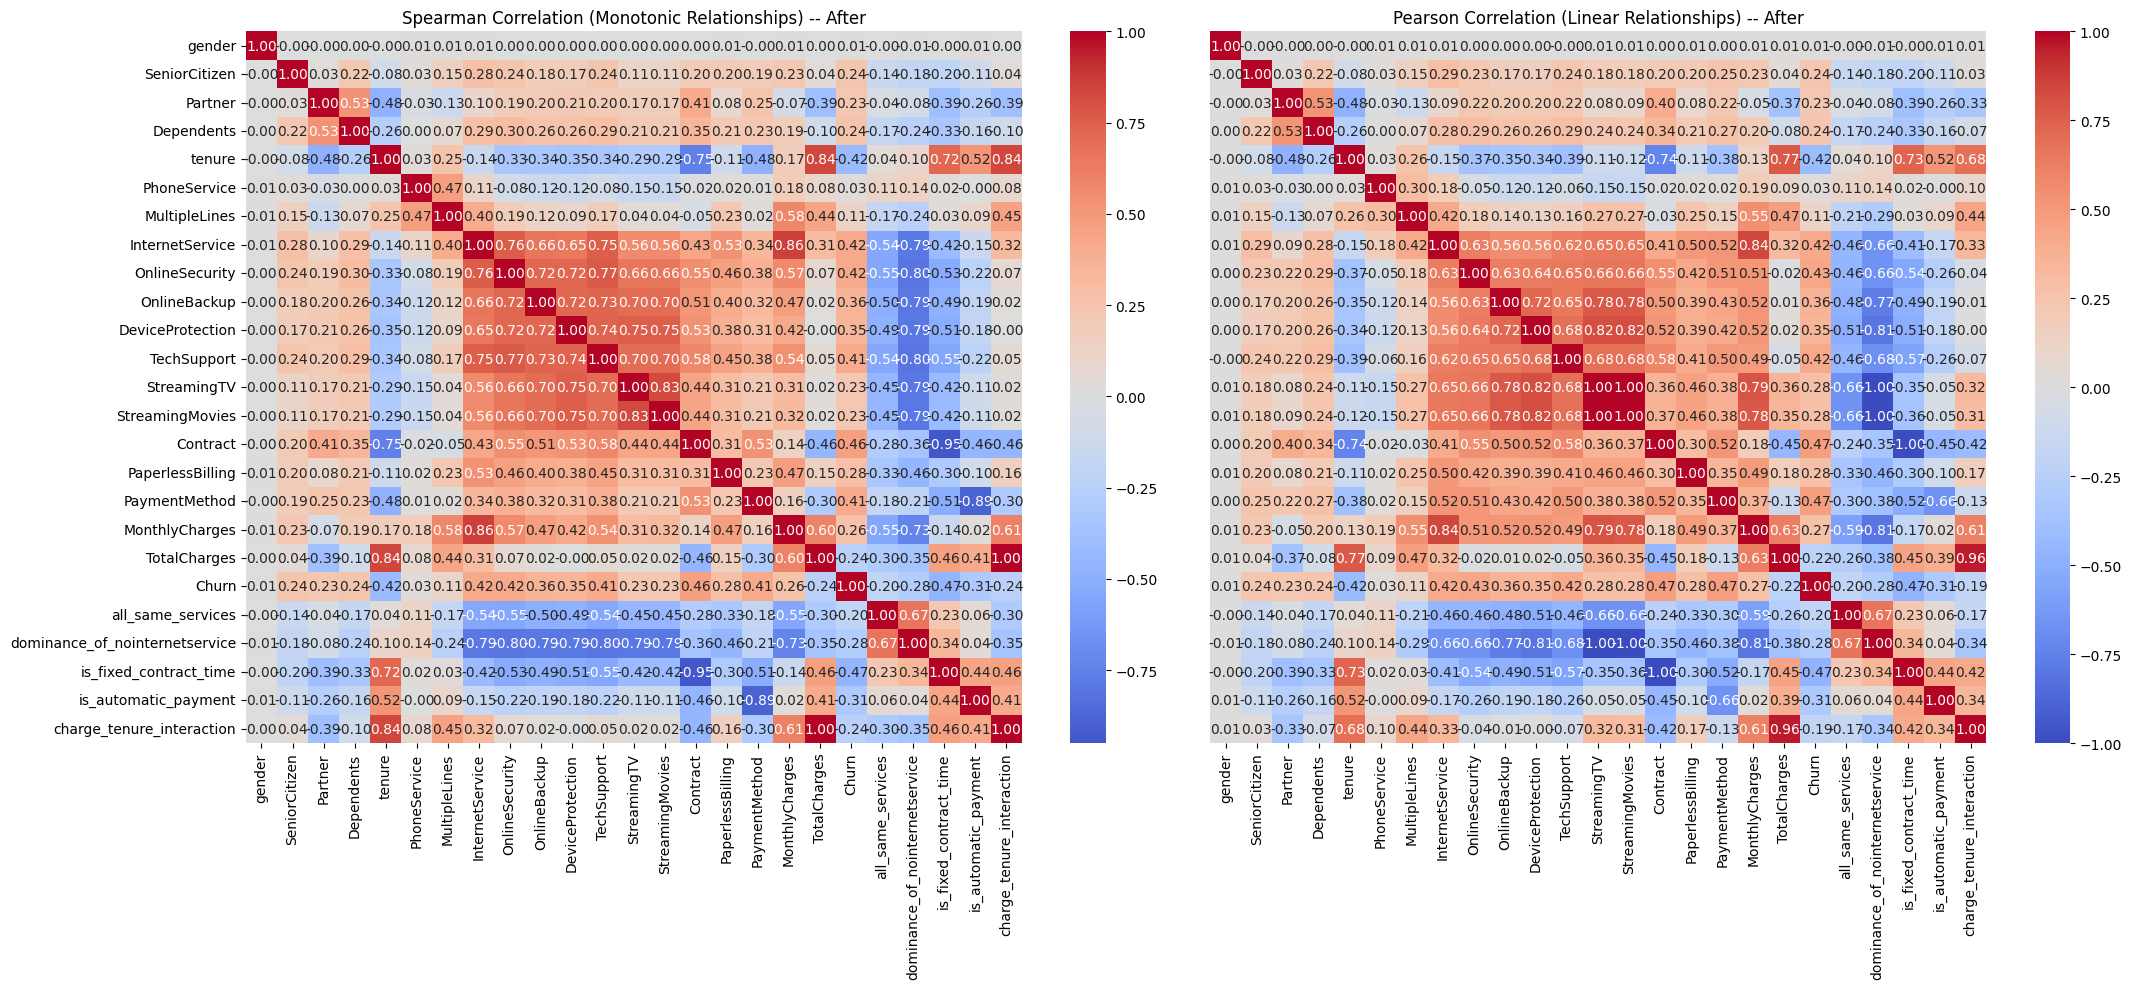

In [489]:
# correlations
spearman_corr = df_og.corr(method="spearman")
kendall_corr  = df_og.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- Before")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- Before")

plt.tight_layout()
plt.show()
# correlations
spearman_corr = df.corr(method="spearman")
kendall_corr  = df.corr(method="pearson")

# one row, two columns
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Spearman
sns.heatmap(
    spearman_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- After")

# Pearson
sns.heatmap(
    kendall_corr.round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    yticklabels=False
)
axes[1].set_title("Pearson Correlation (Linear Relationships) -- After")

plt.tight_layout()
plt.show()

In [490]:
cols = ['dominance_of_nointernetservice', 'PaperlessBilling',
        'PhoneService', 'Dependents', 'SeniorCitizen']

pattern_map = {
    'dominance_of_nointernetservice': 1,
    'PaperlessBilling': 0.07569715952046657,
    'PhoneService': 0.16964551280317983,
    'Dependents': 0.07374328082575766,
    'SeniorCitizen': 1
}


# count matches
df['rarity_factor'] = sum((df[col] == val).astype(int) for col, val in pattern_map.items())
tf['rarity_factor'] = sum((tf[col] == val).astype(int) for col, val in pattern_map.items())

# scale to 0–5 (already 0–len(cols), so normalize)
df['rarity_factor'] = 5 * df['rarity_factor'] / len(cols)
tf['rarity_factor'] = 5 * tf['rarity_factor'] / len(cols)

In [491]:
df.rarity_factor.value_counts()

rarity_factor
0.0    601215
Name: count, dtype: int64

In [492]:
df.Churn.value_counts()

Churn
0    465541
1    135674
Name: count, dtype: int64

In [493]:
df_0 = df[df['Churn'] == 0]
df_1 = df[df['Churn'] == 1]

df_0_down = resample(
    df_0,
    replace=False,
    n_samples=150000,
    random_state=42
)

df = pd.concat([df_0_down, df_1])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"downsampled 'No Churn' in 1.5M!")
df.Churn.value_counts()

downsampled 'No Churn' in 1.5M!


Churn
0    150000
1    135674
Name: count, dtype: int64

In [494]:
target_col = 'Churn'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)


In [495]:
# model
cat = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=12,
    eval_metric="AUC",
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

# probabilities (MANDATORY for ROC)
train_probs = cat.predict_proba(X_train)[:, 1]
test_probs  = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    row = {
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),

        # FIX: use probabilities
        "train_roc": roc_auc_score(y_train, train_probs),
        "test_roc": roc_auc_score(y_test, test_probs)
    }

    rows.append(row)

thresh_df = pd.DataFrame(rows)
print(thresh_df)

    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.474924  0.474937  0.643998  0.644010   0.920505  0.913584
1        0.05   0.701662  0.699174  0.760055  0.757938   0.920505  0.913584
2        0.10   0.752094  0.747363  0.791018  0.787108   0.920505  0.913584
3        0.15   0.781733  0.776580  0.810026  0.805691   0.920505  0.913584
4        0.20   0.800212  0.794199  0.822050  0.816550   0.920505  0.913584
5        0.25   0.813930  0.806753  0.830799  0.824209   0.920505  0.913584
6        0.30   0.824526  0.815691  0.837091  0.829025   0.920505  0.913584
7        0.35   0.832783  0.822295  0.841523  0.831791   0.920505  0.913584
8        0.40   0.838326  0.828409  0.843688  0.834254   0.920505  0.913584
9        0.45   0.841448  0.832167  0.843472  0.834377   0.920505  0.913584
10       0.50   0.842481  0.835107  0.840682  0.833239   0.920505  0.913584
11       0.55   0.841250  0.833683  0.835366  0.827521   0.920505  0.913584
12       0.6

In [496]:
tf_id = tf.pop('id')

In [497]:
submission_cat = pd.DataFrame({
    'id':tf_id,
    'Churn': pd.Series(cat.predict_proba(tf)[:, 1])
})
submission_cat.to_csv('cat_churn_predictions.csv', index=False)
